In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import torch
import torchvision
import torchvision.transforms as transforms

dir_path = "C:\\Users\\vishw\\SIH\\Ai\\drowsiness-detector\\data\\train"
valid_exts = ('.jpg', '.png', '.jpeg' )
corrupted =[]
non_rgb = []
mode_count = {}
class_count = {}

for class_name in os.listdir(dir_path):
    class_path = os.path.join(dir_path, class_name)
    class_count[class_name] = 0

    for root, dirs, files in os.walk(class_path):
        for file in files:
            if not file.lower().endswith(valid_exts):
                continue
            path = os.path.join(root, file)
            
            try:
                with Image.open(path) as img:
                    class_count[class_name] += 1
                    mode = img.mode
                    
                    if mode != 'RGB':
                        non_rgb.append((file, class_name, mode))
                   
                        img = img.convert("RGB")
                        img.save(path)
                        mode = "RGB"
                    mode_count[mode] = mode_count.get(mode, 0)+1
            except:
                corrupted.append((file, class_name))
print("\nClass Distribution:")
for i, j in class_count.items():
    print(f"{i}: {j}")
print("\n Modes:")
for k, v in mode_count.items():
    print(f"{k}: {v}")
print("\nCorrupted files:")
for i in corrupted[:10]:
    print(i)
print("\n Non RGB Images:")
for i in non_rgb[:10]:
    print(i)

In [2]:


transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.RandomRotation(10),
            transforms.RandomHorizontalFlip(10),
            transforms.ColorJitter(
                brightness=0.3,
                contrast = 0.3,
                saturation = 0.2,
                hue = 0.02),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
]) 

val_transform = transforms.Compose([
                transforms.Resize((128, 128)),
                transforms.ToTensor(),
                transforms.Normalize((0.5,0.5,0.5),
                                     (0.5,0.5,0.5))
])



In [3]:
#Dataset 
from torchvision import datasets
dataset = datasets.ImageFolder(
          root="C:\\Users\\vishw\\SIH\\Ai\\drowsiness-detector\\data\\train",
          transform=transform
)
total_size = len(dataset)

#split sizes
train_size = int(total_size*0.7)
val_size = int(total_size*0.15)
test_size = total_size - train_size - val_size

#splitting dataset
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
                                           dataset,
                                           [train_size, val_size, test_size]
)

#assign correct transform
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

In [ ]:
from torch.utils.data import DataLoader
#Dataloaders 
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)
dataiter = iter(train_loader)
images, labels = next(dataiter)
print("Image Shape:", images.shape)
print("Labels Shape:", labels.shape)

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

#model
model = torchvision.models.mobilenet_v2(pretrained =True)

model.classifier[1] = nn.Sequential(
                      nn.Dropout(0.3),
                      nn.Linear(model.classifier[1].in_features, 4))

for param in model.features.parameters():
    param.requires_grad = False
for param in model.features[-2:].parameters():
    param.requires_grad = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda x: x.requires_grad, model.parameters())
                       , lr= 5e-5)
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
#training
train_losses = []
train_accuracies = []
val_losses =[]
val_accuracies = []
lrs =[]
for epoch in range(17):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0 
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad() 
        output  = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() 
        _, preds = torch.max(output, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0) 

    train_loss =  running_loss / len(train_loader)
    train_losses.append(train_loss)
    train_accuracy = correct_train / total_train
    train_accuracies.append(train_accuracy)

    #validation accuracy 

    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            loss = criterion(output, labels)
            running_val_loss += loss.item()
            _, preds = torch.max(output, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0) 

    val_loss = running_val_loss / len(val_loader) 
    val_losses.append(val_loss)
    val_accuracy = correct_val / total_val
    val_accuracies.append(val_accuracy)

    
    current_lr = scheduler.get_last_lr()[0]
    lrs.append(current_lr)
    scheduler.step()

    print(f"\n Epoch: {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.4f}")
    print(f"LR: {current_lr:.6f}")
    

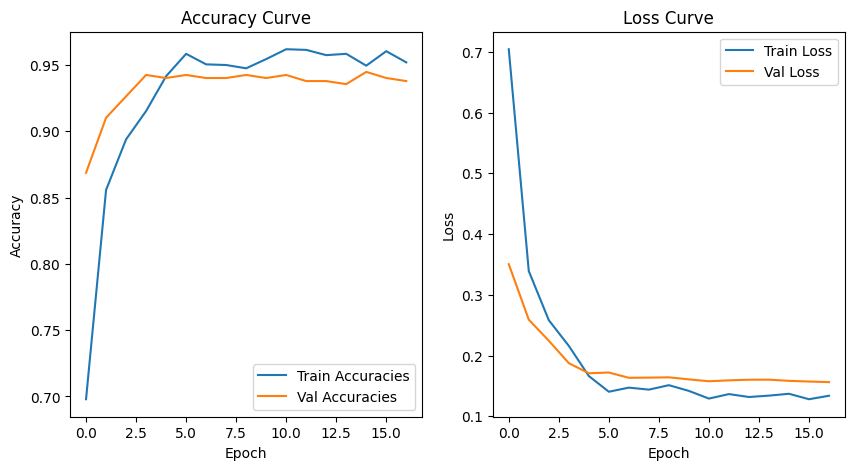

In [7]:
# Accuracy plot
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label = "Train Accuracies")
plt.plot(val_accuracies, label= "Val Accuracies")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")

# loss plot
plt.subplot(1,2,2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")

plt.show()

In [8]:
torch.save(model.state_dict(), "drowsiness_model.pth")

In [9]:
model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_loss = test_loss / len(test_loader)
test_acc = correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.1502
Test Accuracy: 0.9427


In [10]:
from sklearn.metrics import confusion_matrix
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[108   1   0   0]
 [  1 121   0   0]
 [  0   0  94  10]
 [  0   0  13  88]]


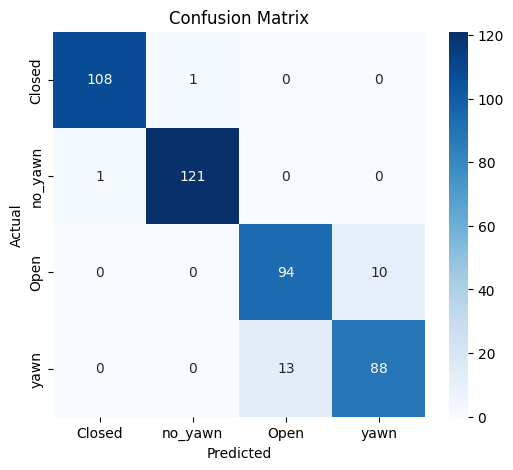

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ['Closed', 'no_yawn', 'Open', 'yawn']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()